# Jackson-Fischer 2020 — Breast Cancer IMC EDA (Full)

Exploratory data analysis of the Jackson & Fischer et al. 2020 breast cancer dataset,
acquired by Imaging Mass Cytometry (IMC).

Full cohort: 285 patients, 1,240,267 cells, 45 IMC markers.
Expression matrix: raw ion counts in X, arcsinh-transformed in layers["exprs"].

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "../..")

import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data.dataset_EDA import (
    JACKSON_CFG,
    summarize_metadata, spatial_info, cat_breakdown,
    plot_sample, plot_samples, plot_all_samples,
)

CFG = JACKSON_CFG

## Load Data

In [2]:
DATA_PATH       = "../../../data/jacksonfischer2020/full/full.h5ad"
CHECKPOINT_PATH = "../../../data/jacksonfischer2020/full/full_processed.h5ad"

adata_raw = ad.read_h5ad(DATA_PATH)
adata_raw

AnnData object with n_obs × n_vars = 1240267 × 45
    obs: 'image_name', 'cell_id', 'neighbors_number', 'neighbors_percent_touching', 'cell_area', 'cell_perimeter', 'cell_eccentricity', 'cell_euler_number', 'cell_extent', 'cell_major_axis_length', 'cell_minor_axis_length', 'cell_orientation', 'cell_solidity', 'cell_x', 'cell_y', 'cell_cluster_phenograph', 'cell_metacluster', 'image_number', 'cells_per_image', 'image_width', 'image_height', 'image_area', 'image_filename', 'image_sum_area_cells', 'image_percent_tumor_cells', 'image_percent_normal_epithelial_cells', 'image_percent_stroma', 'image_percent_inflammatory_cells', 'patient_id', 'patient_age', 'patient_gender', 'patient_status', 'patient_disease_status', 'pateint_menopausal', 'patient_DFS_months', 'patient_OS_months', 'patient_year_sample_collection', 'TMA_location', 'TMA_x', 'TMA_y', 'TMA_block_label', 'TMA_UBTMA_location', 'tumor_grade', 'tumor_type', 'tumor_subtype', 'tumor_clinical_type', 'tumor_location', 'tumor_size', 'tum

In [3]:
# Re-run this cell to restore clean state without restarting kernel
adata = adata_raw.copy()

## Dataset Overview

In [4]:
summarize_metadata(adata, cfg=CFG)

Cells:   1,240,267
Markers: 45
Samples: 723

Obs columns (76):
  image_name, cell_id, neighbors_number, neighbors_percent_touching, cell_area, cell_perimeter, cell_eccentricity, cell_euler_number, cell_extent, cell_major_axis_length, cell_minor_axis_length, cell_orientation, cell_solidity, cell_x, cell_y, cell_cluster_phenograph, cell_metacluster, image_number, cells_per_image, image_width, image_height, image_area, image_filename, image_sum_area_cells, image_percent_tumor_cells, image_percent_normal_epithelial_cells, image_percent_stroma, image_percent_inflammatory_cells, patient_id, patient_age, patient_gender, patient_status, patient_disease_status, pateint_menopausal, patient_DFS_months, patient_OS_months, patient_year_sample_collection, TMA_location, TMA_x, TMA_y, TMA_block_label, TMA_UBTMA_location, tumor_grade, tumor_type, tumor_subtype, tumor_clinical_type, tumor_location, tumor_size, tumor_primary_site, tumor_primary_diagnosis, tumor_ER_status, tumor_HER2_status, tumor_HR_stat

/cv/scratch/u/ratzana/spatialproteomics/sp-ml/notebooks/../data/dataset_EDA.py:187: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return series.astype(object).fillna("NA").astype(str)


  patient_id                285 unique  ['1', '10', '100', '101', '102', '103']...
  patient_cohort              2 unique  ['Basel', 'Zurich']
  tumor_subtype               5 unique  ['PR+ER+', 'PR+ER-', 'PR-ER+', 'PR-ER-', 'nan']
  tumor_ER_status             3 unique  ['nan', 'negative', 'positive']
  tumor_PR_status             3 unique  ['nan', 'negative', 'positive']
  tumor_HER2_status           3 unique  ['nan', 'negative', 'positive']


/cv/scratch/u/ratzana/spatialproteomics/sp-ml/notebooks/../data/dataset_EDA.py:187: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return series.astype(object).fillna("NA").astype(str)


  tumor_grade                 3 unique  ['1', '2', '3']
  cell_metacluster           27 unique  ['1.0', '10.0', '11.0', '12.0', '13.0', '14.0']...
  tumor_response              4 unique  ['Refractory', 'Resistant', 'Sensitive', 'nan']

Protein expression summary (across all cells):
  Protein                         Min     Median        Max
  ────────────────────────────────────────────────────────
  Ru96                          0.000      1.687    232.027
  Ru98                          0.000      0.494     30.802
  Ru99                          0.000      3.122     57.726
  Ru100                         0.000      2.963     55.295
  Ru101                         0.000      4.006     73.727
  Ru102                         0.000      7.782    137.706
  Ru104                         0.000      5.670    102.721
  H3                            0.000      6.233    238.153
  H3K27me3                      0.000      0.548    161.714
  KRT5                          0.000      0.112    204.39

In [5]:
spatial_info(adata)

x: [0.0, 1030.2]  range = 1030.2
y: [0.0, 880.6]  range = 880.6
Estimated resolution (median NN spacing): 6.33 units


In [6]:
cat_breakdown(adata, cfg=CFG)


────────────────────────────────────────────
image_name  (723 unique)
image_name
BaselTMA_SP43_168_X10Y5        6908
BaselTMA_SP42_127_X2Y8         6845
BaselTMA_SP43_108_X13Y8        6320
BaselTMA_SP43_144_X15Y1        6267
BaselTMA_SP43_116_X3Y4         6069
BaselTMA_SP43_173_X2Y8         5802
BaselTMA_SP41_141_X11Y2        5662
BaselTMA_SP43_93_X15Y5         5285
BaselTMA_SP43_226_X6Y9         5282
BaselTMA_SP42_179_X13Y8        5186
BaselTMA_SP43_102_X1Y4         5151
BaselTMA_SP43_128_X16Y7        5104
BaselTMA_SP43_111_X8Y6         5057
BaselTMA_SP42_82_X2Y9          5024
BaselTMA_SP43_115_X4Y8         4931
BaselTMA_SP41_186_X5Y4         4923
BaselTMA_SP42_64_X14Y4         4833
BaselTMA_SP42_176_X3Y7         4769
BaselTMA_SP41_88_X11Y5_235     4713
BaselTMA_SP43_245_X6Y5         4628
BaselTMA_SP42_155_X4Y9         4585
BaselTMA_SP41_117_X13Y3        4572
BaselTMA_SP41_11_X13Y7         4565
BaselTMA_SP41_191_X15Y7        4544
BaselTMA_SP41_92_X12Y7         4533
BaselTMA_SP42_59_X

## Single Sample Viewer

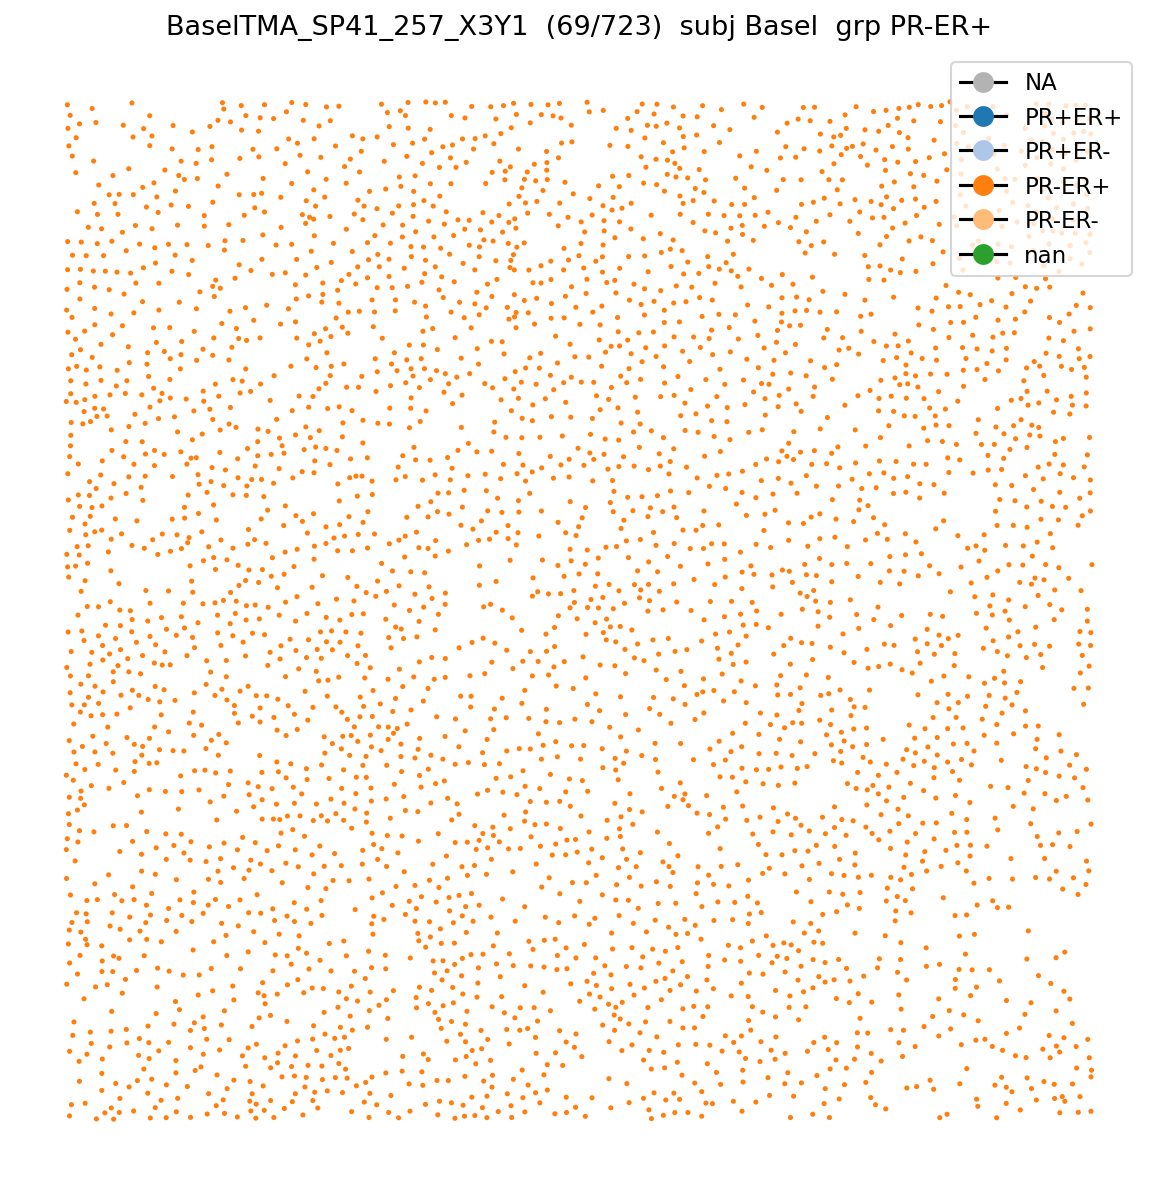

In [7]:
sample = adata.obs["image_name"].unique()[0]
plot_sample(adata, sample_id=sample, color_by="cell_metacluster", cfg=CFG)

## Subsample Viewer

8 of 285 images, shared legend.

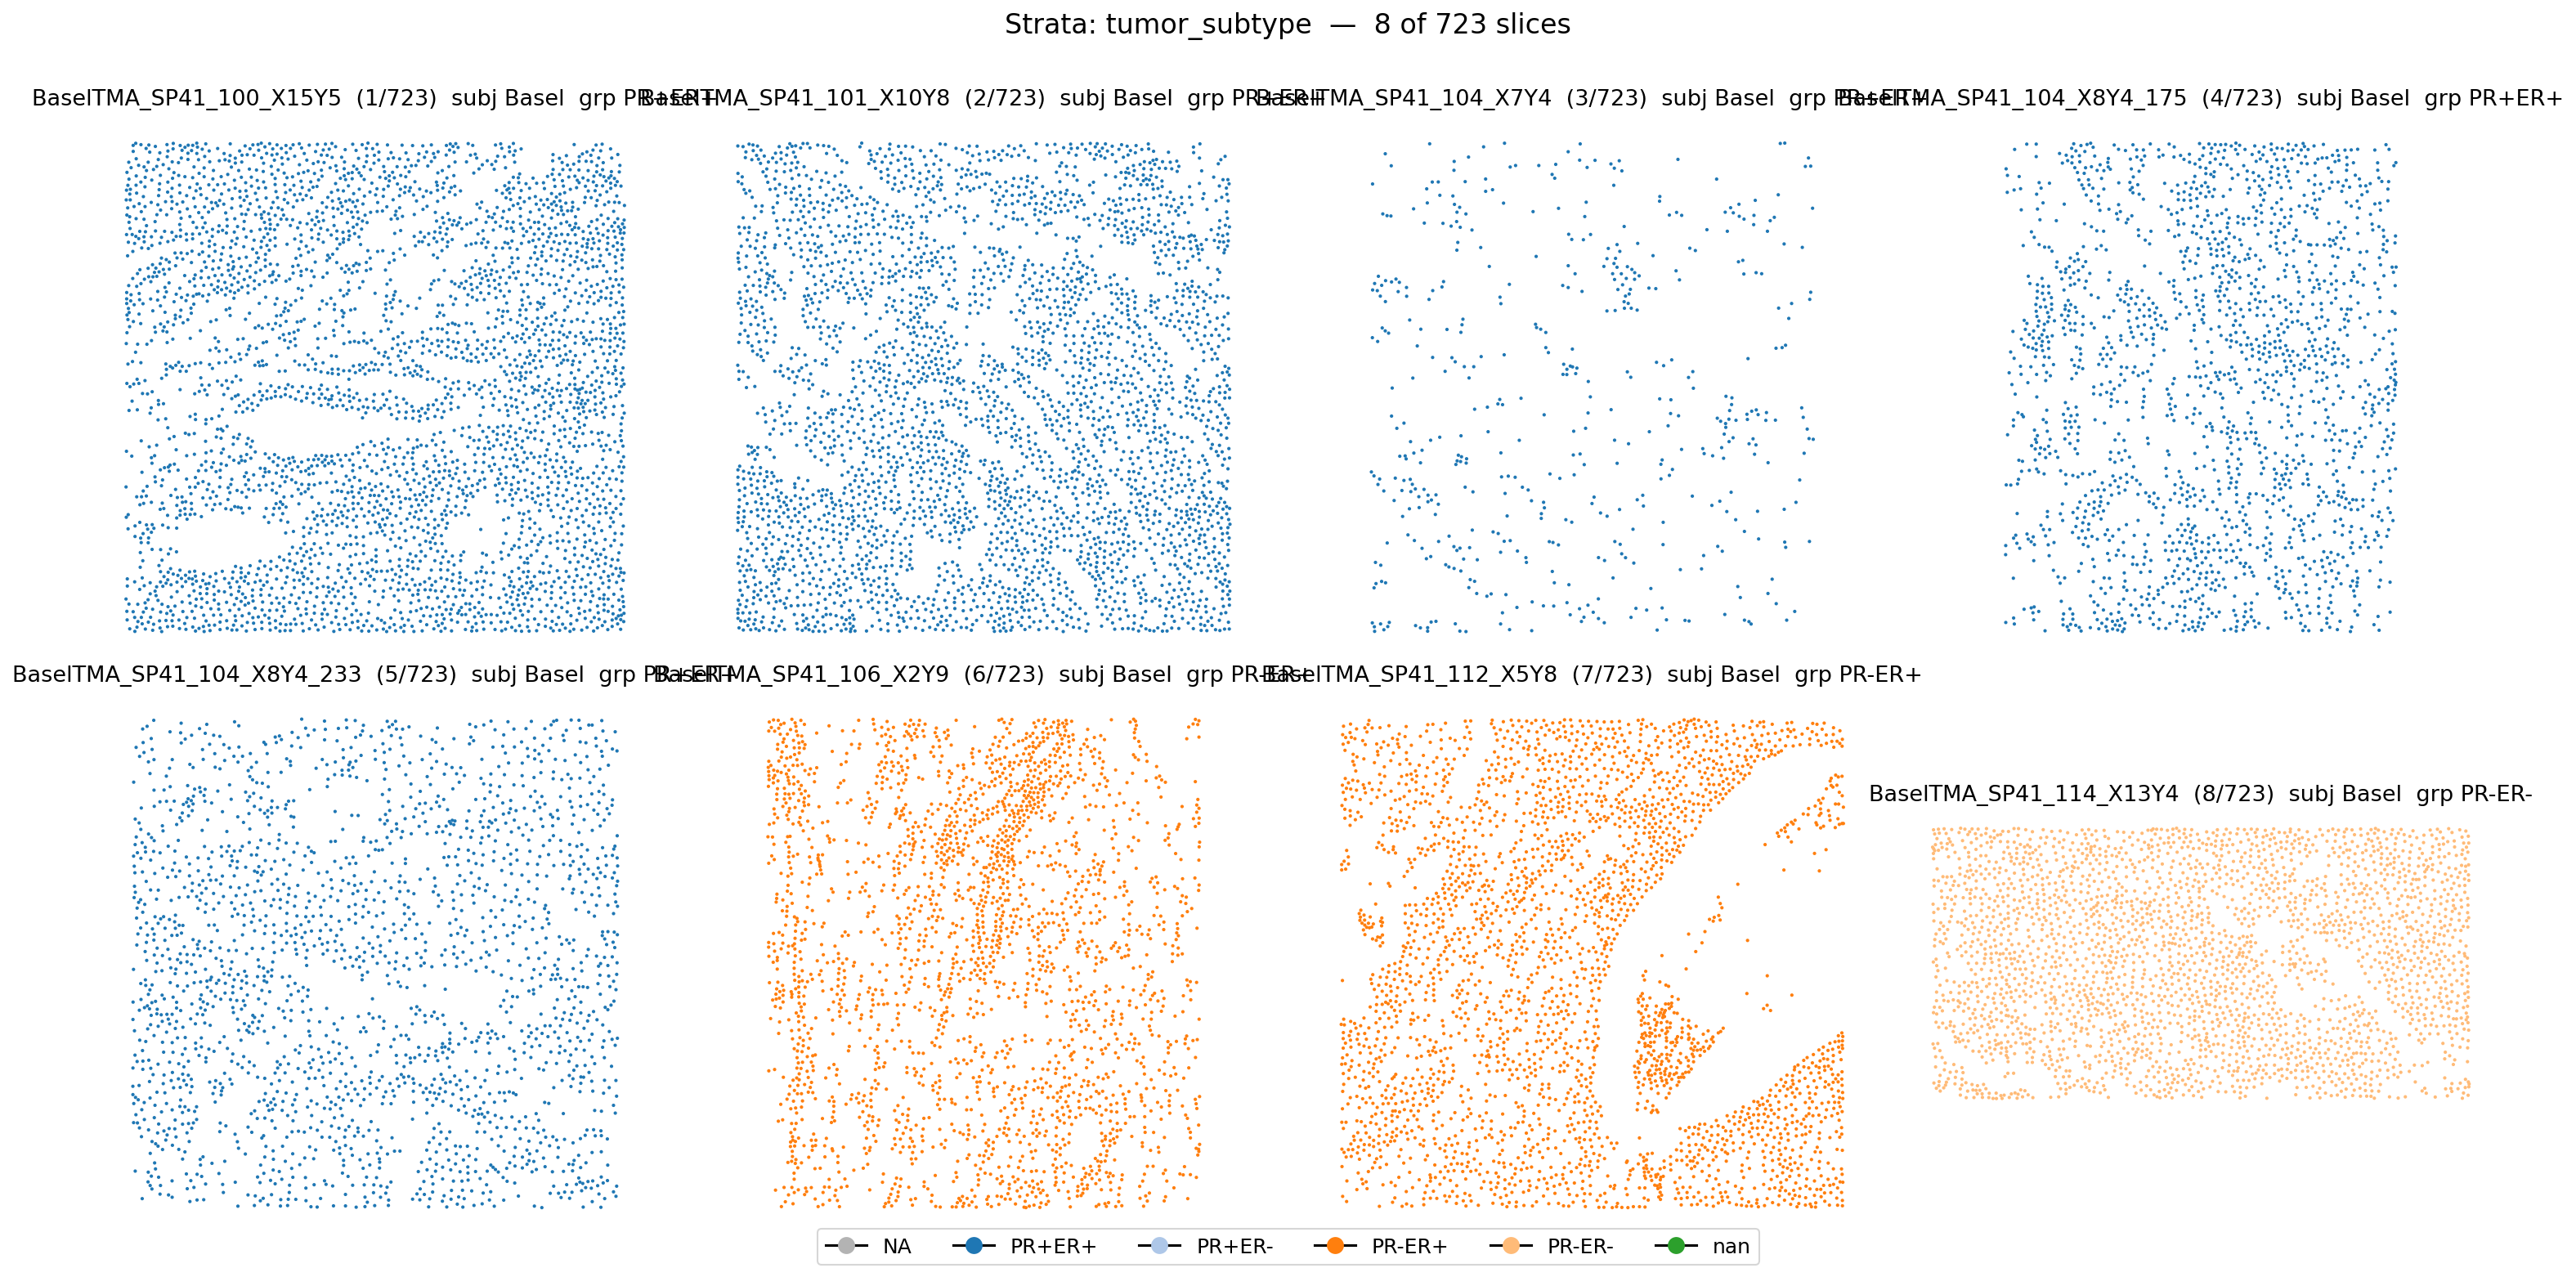

In [8]:
plot_samples(adata, n_cols=4, color_by="tumor_subtype", cfg=CFG)